## 📦 Kütüphaneleri İçe Aktar

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print("Libraries imported successfully!")

Libraries imported successfully!


## 📂 Veri Setini Yükle

In [2]:
# Kaggle dataset path
DATA_PATH = '/kaggle/input/bank-customer-churn-dataset/Bank Customer Churn Prediction.csv'

# Load data
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (10000, 12)


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 🔧 Özellikleri Tanımla

In [3]:
# Define feature columns
numerical_cols = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary']
categorical_cols = ['country', 'gender']  # OHE için
binary_cols = ['credit_card', 'active_member']  # Olduğu gibi kalacak

# All features
all_features = numerical_cols + categorical_cols + binary_cols

# X and y
X = df[all_features]
y = df['churn']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nChurn distribution:\n{y.value_counts()}")

Features shape: (10000, 10)
Target shape: (10000,)

Churn distribution:
churn
0    7963
1    2037
Name: count, dtype: int64


## ✂️ Train-Test Ayrımı

In [4]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"\nTrain churn distribution:\n{y_train.value_counts()}")
print(f"\nTest churn distribution:\n{y_test.value_counts()}")

Train set size: (8000, 10)
Test set size: (2000, 10)

Train churn distribution:
churn
0    6370
1    1630
Name: count, dtype: int64

Test churn distribution:
churn
0    1593
1     407
Name: count, dtype: int64


## 🔧 Ön İşleme Pipeline'ı Oluştur

In [5]:
# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'  # Binary columns (credit_card, active_member) olduğu gibi kalacak
)

print("Preprocessing pipeline created!")
print(f"\nNumerical columns (RobustScaler): {numerical_cols}")
print(f"Categorical columns (OneHotEncoder): {categorical_cols}")
print(f"Binary columns (passthrough): {binary_cols}")

Preprocessing pipeline created!

Numerical columns (RobustScaler): ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary']
Categorical columns (OneHotEncoder): ['country', 'gender']
Binary columns (passthrough): ['credit_card', 'active_member']


## 🔄 Veriyi Ön İşle

In [6]:
# Create full pipeline: preprocessing + model
baseline_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

print("Baseline pipeline created!")
print(baseline_pipeline)

Baseline pipeline created!
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', RobustScaler(),
                                                  ['credit_score', 'age',
                                                   'tenure', 'balance',
                                                   'products_number',
                                                   'estimated_salary']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['country', 'gender'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])


## 🤖 Baseline Model Eğit (Logistic Regression)

In [7]:
# Train the model
print("Training baseline model...")
baseline_pipeline.fit(X_train, y_train)
print("✅ Model training completed!")

Training baseline model...
✅ Model training completed!


## 📊 Model Tahminleri Yap

In [8]:
# Predictions
y_train_pred = baseline_pipeline.predict(X_train)
y_test_pred = baseline_pipeline.predict(X_test)

# Prediction probabilities
y_train_proba = baseline_pipeline.predict_proba(X_train)[:, 1]
y_test_proba = baseline_pipeline.predict_proba(X_test)[:, 1]

print("Predictions completed!")

Predictions completed!


## 📈 Model Performansını Değerlendir

In [9]:
# Calculate metrics
train_metrics = {
    'Accuracy': accuracy_score(y_train, y_train_pred),
    'Precision': precision_score(y_train, y_train_pred),
    'Recall': recall_score(y_train, y_train_pred),
    'F1-Score': f1_score(y_train, y_train_pred),
    'ROC-AUC': roc_auc_score(y_train, y_train_proba)
}

test_metrics = {
    'Accuracy': accuracy_score(y_test, y_test_pred),
    'Precision': precision_score(y_test, y_test_pred),
    'Recall': recall_score(y_test, y_test_pred),
    'F1-Score': f1_score(y_test, y_test_pred),
    'ROC-AUC': roc_auc_score(y_test, y_test_proba)
}

# Display results
results_df = pd.DataFrame({
    'Train': train_metrics,
    'Test': test_metrics
})

print("\n" + "="*50)
print("📊 BASELINE MODEL PERFORMANCE METRICS")
print("="*50)
print(results_df)
print("="*50)


📊 BASELINE MODEL PERFORMANCE METRICS
              Train      Test
Accuracy   0.810625  0.808000
Precision  0.598628  0.589147
Recall     0.214110  0.186732
F1-Score   0.315409  0.283582
ROC-AUC    0.765461  0.774833


## 💾 Baseline Sonuçlarını Kaydet

In [10]:
print("\n📋 Classification Report (Test Set):")
print("="*50)
print(classification_report(y_test, y_test_pred, target_names=['Not Churned', 'Churned']))


📋 Classification Report (Test Set):
              precision    recall  f1-score   support

 Not Churned       0.82      0.97      0.89      1593
     Churned       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



## 🔍 Confusion Matrix Görselleştir

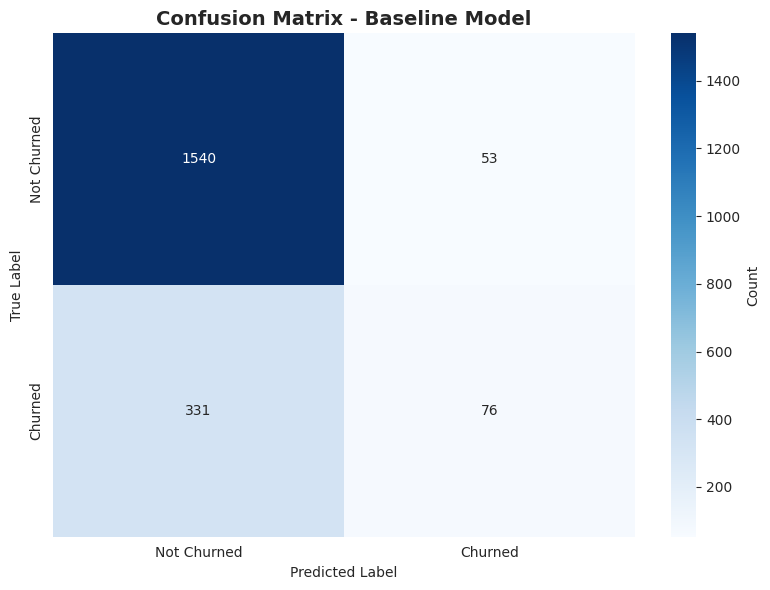


True Negatives: 1540
False Positives: 53
False Negatives: 331
True Positives: 76


In [11]:
# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Baseline Model', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print(f"\nTrue Negatives: {cm[0, 0]}")
print(f"False Positives: {cm[0, 1]}")
print(f"False Negatives: {cm[1, 0]}")
print(f"True Positives: {cm[1, 1]}")

## 📝 Baseline Sonuçları Özeti

### Model: Logistic Regression

**Performans Metrikleri:**
- **Accuracy:** [0.8080]
- **Precision:** [0.5891]
- **Recall:** [0.1867]
- **F1-Score:** [0.2836]
- **ROC-AUC:** [0.7748]

### Yorumlama:

Bu baseline model:
- ✅ Basit ve yorumlanabilir
- ✅ Hızlı eğitim
- ⚠️ Doğrusal varsayımlar
- ⚠️ Karmaşık ilişkileri yakalayamayabilir

### Sonraki Adımlar:
1. **Özellik Mühendisliği** - Yeni özellikler oluştur
2. **Gelişmiş Modeller** - XGBoost, LightGBM, CatBoost dene
3. **Hiperparametre Optimizasyonu** - En iyi parametreleri bul
4. **Ensemble Yöntemleri** - Birden fazla modeli birleştir

Bu baseline, iyileştirme için bir başlangıç noktası sağlar! 🚀